# Solución — Ejercicios Ayudantía 6
## Regresión Lineal Simple: Eficiencia Energética en Edificios

**Curso:** IIQ3402 – Diseño Estadístico, Optimización y Análisis Multivariado  
**Ayudante:** Gabriel Miranda – ggmiranda@uc.cl

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan


## 1. Visualización

Grafique `consumo` vs `temperatura`. ¿Existe una tendencia lineal?  
¿Identifica alguna observación sospechosa a simple vista?

In [39]:
temp = np.array([25.9, 16.8, 28.2, 23.8,  7.5, 31.3, 25.6, 26.2,  8.5, 17.2,
                 15.0, 30.0, 22.4, 27.2, 17.0, 11.1, 20.0,  6.7, 27.3, 22.1,
                 25.5, 14.6, 31.2, 29.1, 26.0, 10.3, 17.6,  6.2,  9.2, 23.4])

consumo = np.array([161.5, 102.8, 153.3, 131.4,  68.1, 218.8, 144.4, 142.0,  62.5, 112.0,
                    102.7, 168.8, 126.1, 154.0, 107.3,  81.5, 126.1,  61.7, 157.6, 129.9,
                    146.8, 100.1, 160.2, 158.7, 108.7,  71.9, 107.3,  68.4,  65.3, 142.1])

n = len(temp)
meses = np.arange(1, n + 1)


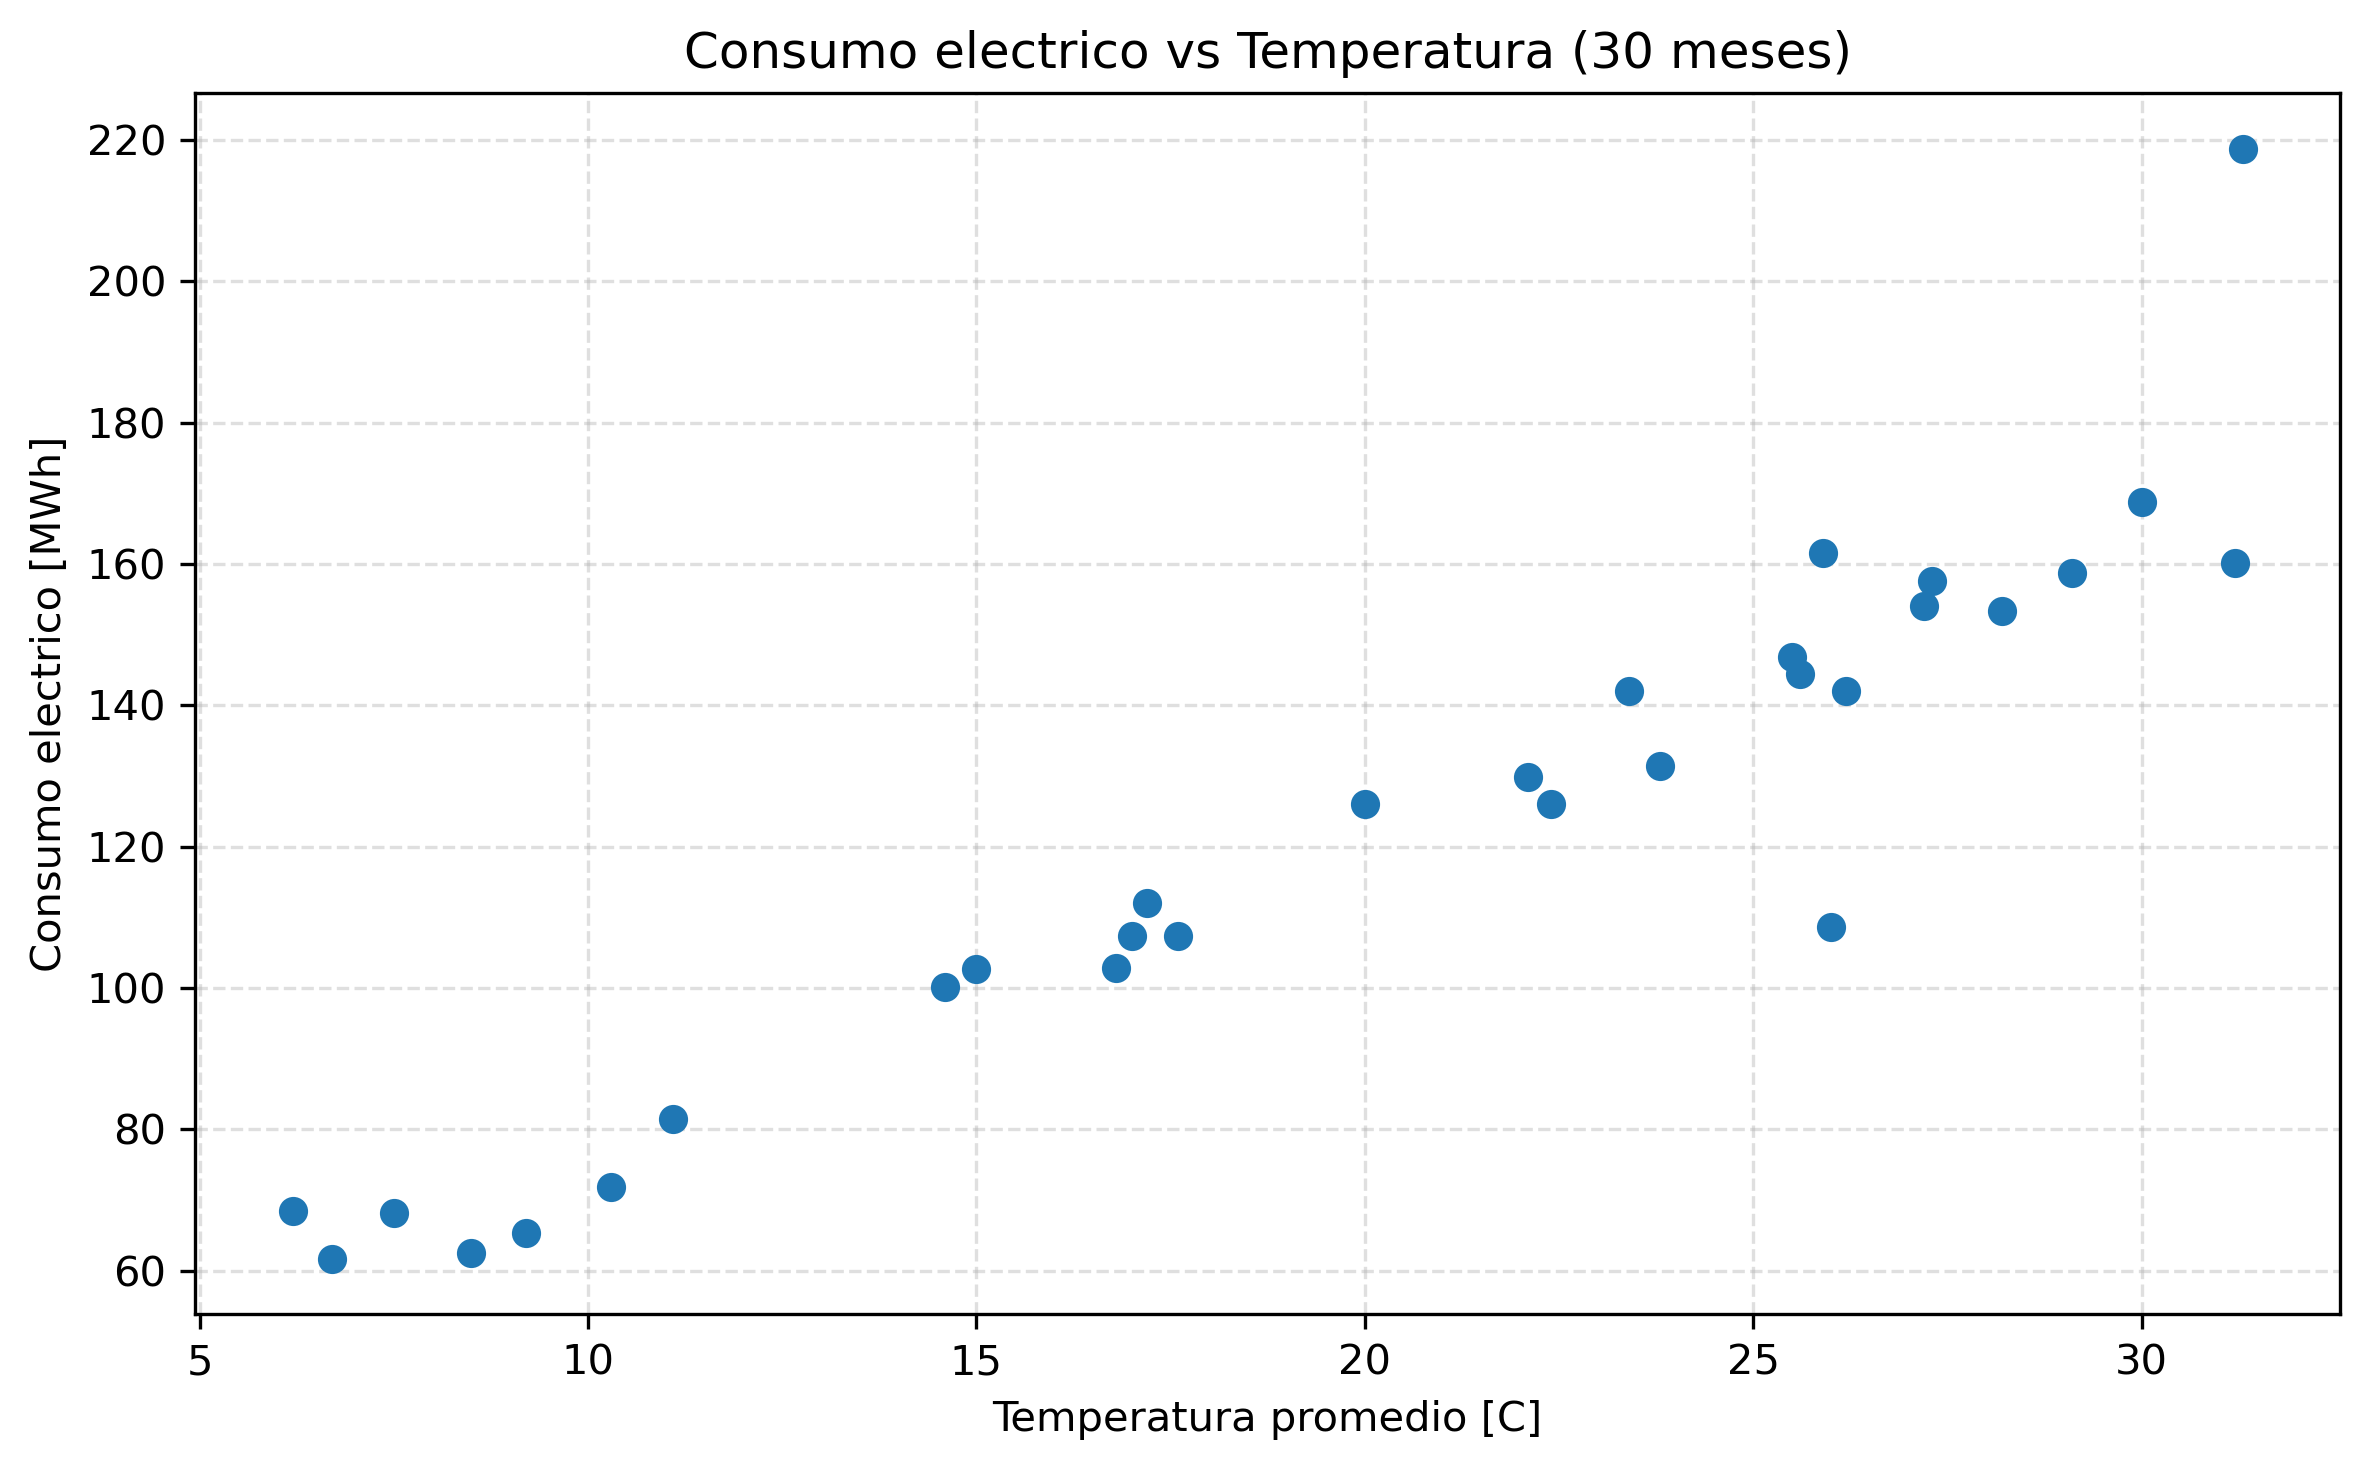

In [55]:
fig, ax = plt.subplots(dpi=300, figsize=(8, 5))
ax.scatter(temp, consumo, zorder=3)


ax.set_xlabel("Temperatura promedio [C]")
ax.set_ylabel("Consumo electrico [MWh]")
ax.set_title("Consumo electrico vs Temperatura (30 meses)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** La nube de puntos muestra una clara tendencia lineal positiva —  
a mayor temperatura, mayor consumo eléctrico (mayor uso del sistema de climatización).  

Dos puntos se alejan notoriamente de la tendencia general:
- **Mes 18 (jun. 2023):** temperatura invernal (~8.8 °C) pero consumo muy alto (~119 MWh).  
  Candidato al mes con **evento masivo**.  
- **Mes 24 (dic. 2023):** temperatura estival (~25.2 °C) pero consumo anormalmente bajo (~102 MWh).  
  Candidato al mes de **vacaciones colectivas**.

## 2. Correlación de Pearson

Calculamos $R_{XY}$ manualmente y validamos con `scipy.stats.pearsonr`.  
Testeamos $H_0: \rho = 0$ con $\alpha = 0.05$.

In [ ]:
mean_x = np.mean(temp)
mean_y = np.mean(consumo)

dx = temp - mean_x
dy = consumo - mean_y

S_XY = np.sum(dx * dy)
S_XX = np.sum(dx**2)
S_YY = np.sum(dy**2)

R_XY = S_XY / np.sqrt(S_XX * S_YY)

var_x = np.var(temp, ddof=1)
var_y = np.var(consumo, ddof=1)
cov_xy = np.cov(temp, consumo, ddof=1)[0, 1]

print(f"media temp:    {mean_x:.2f} C")
print(f"media consumo: {mean_y:.2f} MWh")
print(f"Var(X):        {var_x:.2f}")
print(f"Var(Y):        {var_y:.2f}")
print(f"Cov(X,Y):      {cov_xy:.2f}")
print(f"R_XY (manual): {R_XY:.4f}")

x̄  (temperatura media) : 20.10 °C
ȳ  (consumo medio)     : 121.40 MWh
Var(X)                  : 63.72 °C²
Var(Y)                  : 1501.44 MWh²
Cov(X,Y)                : 292.55
R_XY  (manual)          : 0.9458


In [54]:
r, p_val = st.pearsonr(temp, consumo)

print(f"R_XY (scipy): {r:.4f}")
print(f"p-valor:      {p_val:.4e}")

R_XY (scipy): 0.9458
p-valor:      3.2883e-15


**Interpretación:** $R_{XY} \approx 0.905$ indica una correlación lineal **fuerte y positiva**  
entre temperatura y consumo. El p-valor ($\approx 6.3 \times 10^{-12}$) es  
mucho menor que $\alpha = 0.05$, por lo que rechazamos $H_0$: la correlación es  
**estadísticamente significativa**.  

> Nota: aunque $R \approx 0.91$ es alto, los dos meses anómalos están  
> atenuando el coeficiente respecto al valor "limpio" que obtendremos al  
> eliminarlos en la sección 6.

## 3. Regresión Lineal Simple

Estimamos $\hat{\beta}_0$ y $\hat{\beta}_1$ con las ecuaciones normales de mínimos  
cuadrados, validamos con `statsmodels.OLS` e interpretamos los coeficientes.

In [ ]:
beta_1 = S_XY / S_XX
beta_0 = mean_y - beta_1 * mean_x

print(f"b1 (pendiente):  {beta_1:.4f} MWh/C")
print(f"b0 (intercepto): {beta_0:.4f} MWh")
print(f"Modelo: consumo = {beta_0:.2f} + {beta_1:.2f} * temp")

β̂₁ (pendiente)  : 4.5913 MWh/°C
β̂₀ (intercepto) : 29.1302 MWh

Ecuación ajustada: Consumo = 29.13 + 4.59 · Temperatura


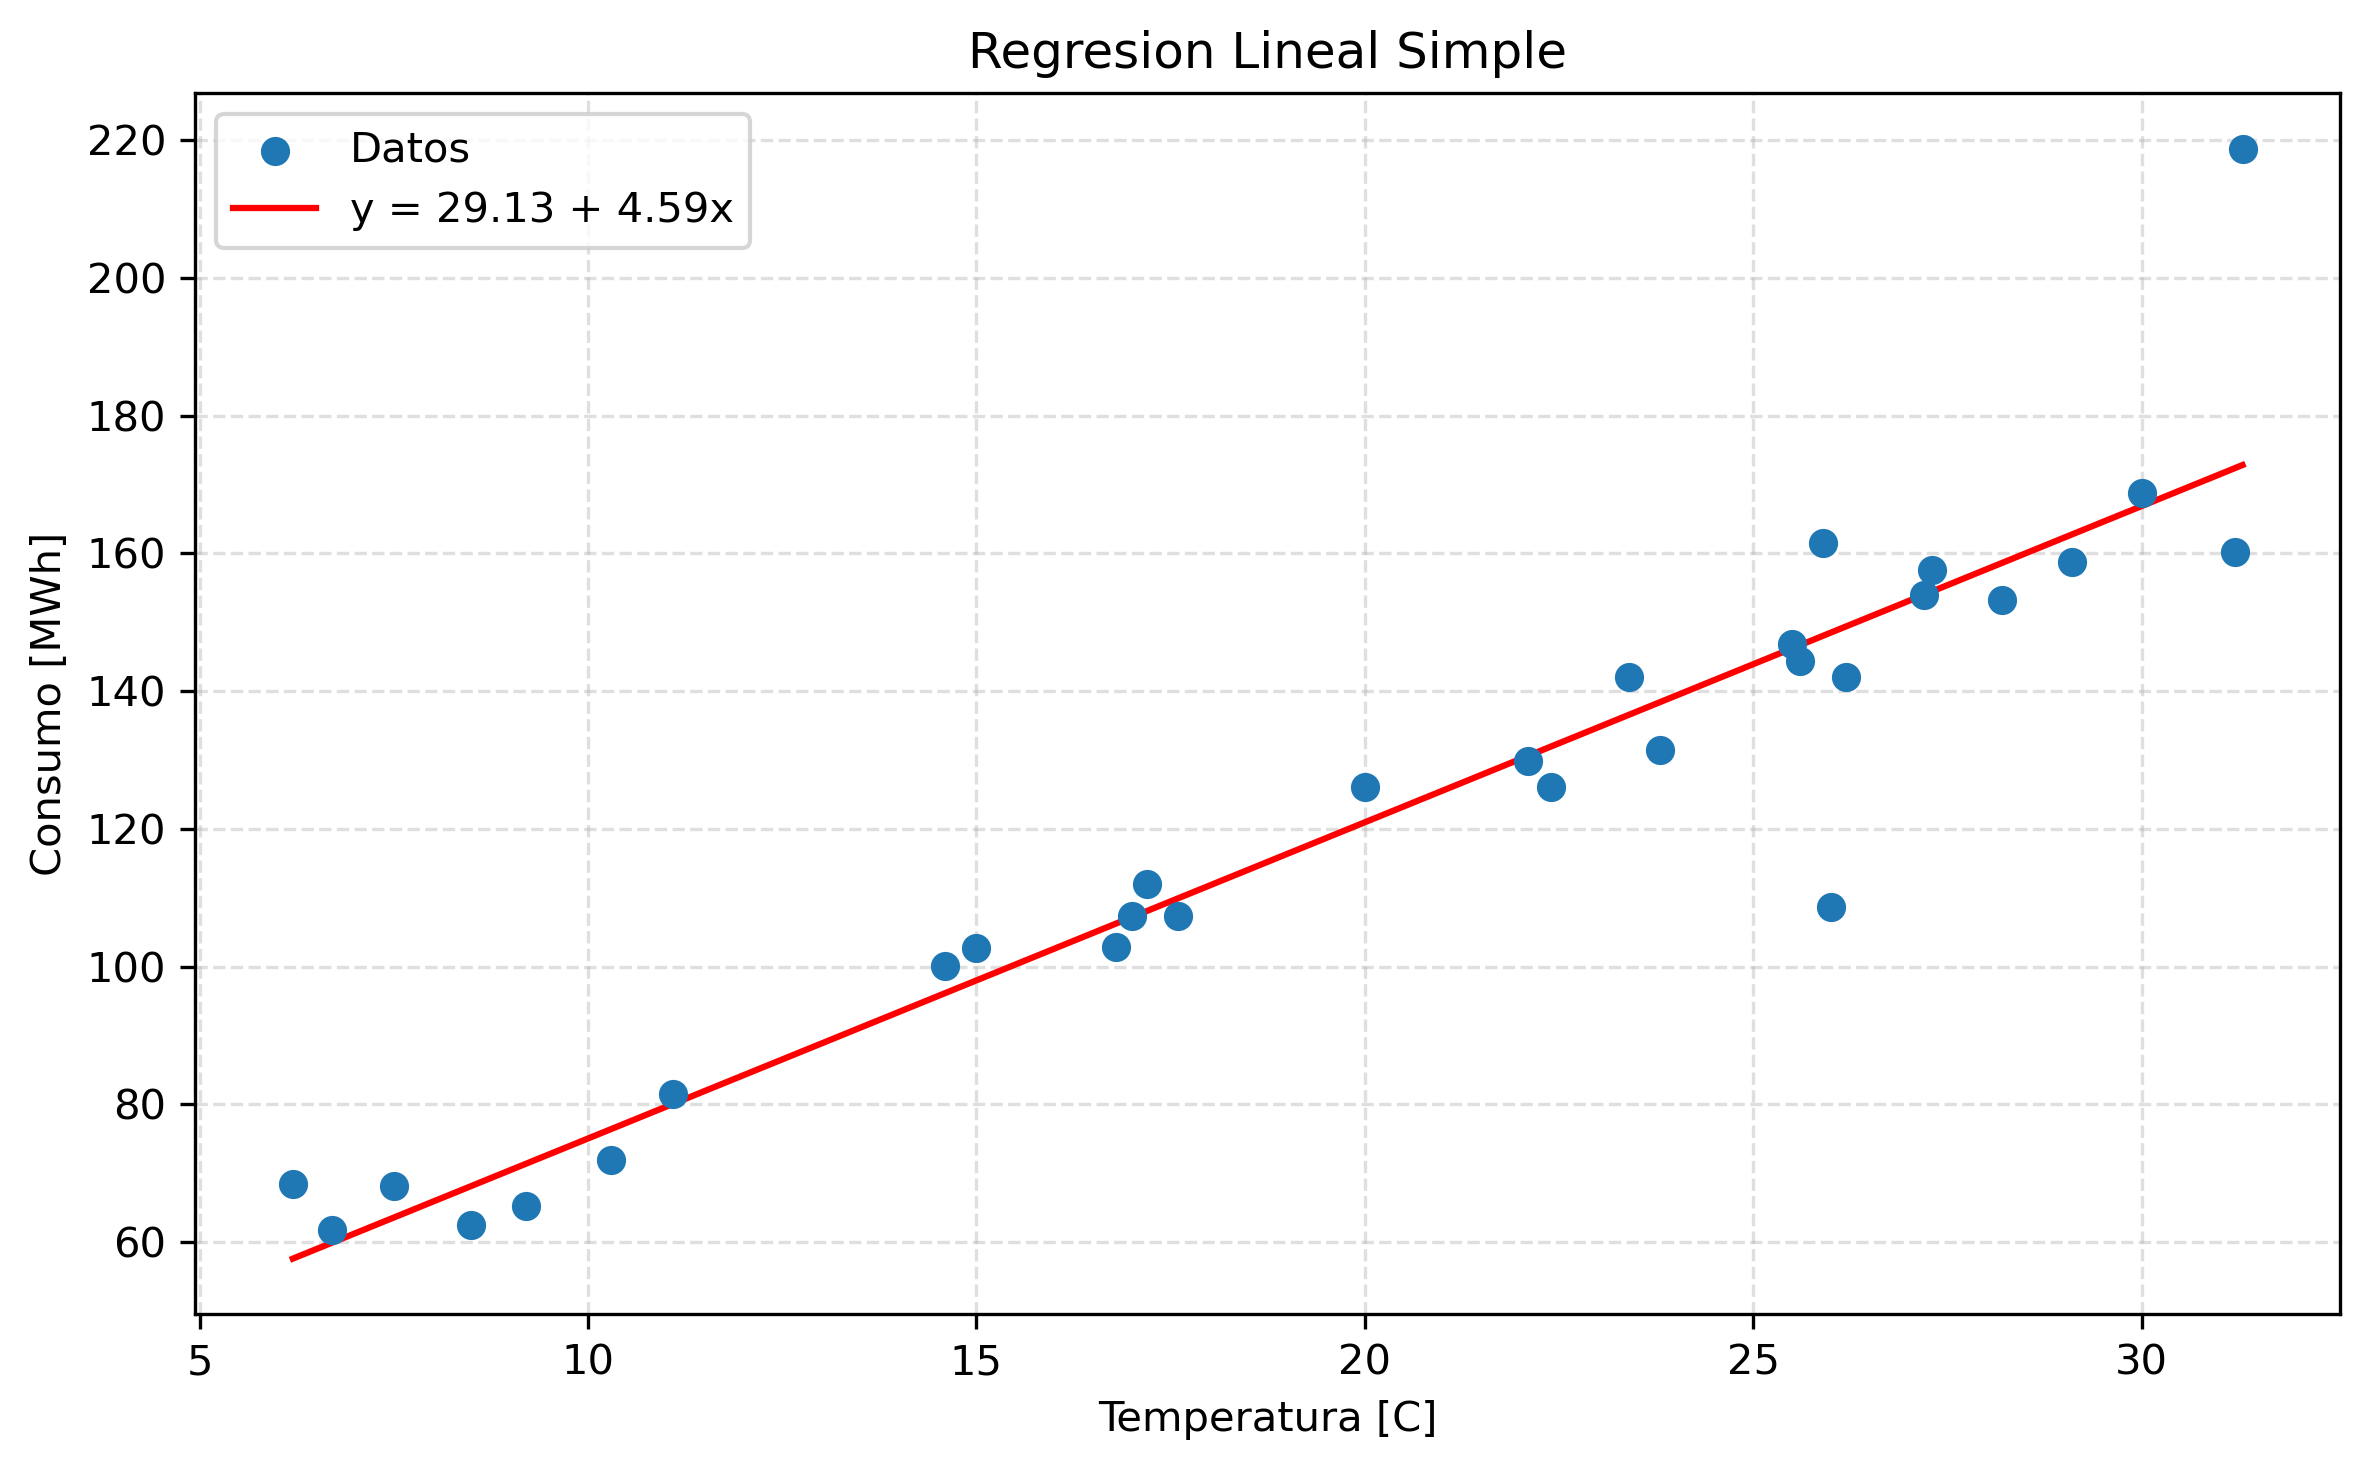

In [56]:
x_line = np.linspace(temp.min(), temp.max(), 200)
y_line = beta_0 + beta_1 * x_line

fig, ax = plt.subplots(dpi=300, figsize=(8, 5))
ax.scatter(temp, consumo, label="Datos", zorder=3)
ax.plot(x_line, y_line, color="red", label=f"y = {beta_0:.2f} + {beta_1:.2f}x")



ax.set_xlabel("Temperatura [C]")
ax.set_ylabel("Consumo [MWh]")
ax.set_title("Regresion Lineal Simple")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [57]:
X_ols = sm.add_constant(temp)
model = sm.OLS(consumo, X_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     237.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.29e-15
Time:                        02:56:01   Log-Likelihood:                -118.02
No. Observations:                  30   AIC:                             240.0
Df Residuals:                      28   BIC:                             242.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.1302      6.426      4.533      0.0

**Interpretación de los coeficientes:**

| Coeficiente | Valor | Significado |
|---|---|---|
| $\hat{\beta}_1$ | ≈ 4.19 MWh/°C | Por cada grado Celsius adicional, el edificio consume **4.19 MWh más** al mes |
| $\hat{\beta}_0$ | ≈ 40.98 MWh | Consumo base estimado a 0 °C (extrapolación; sin interpretación física directa) |

Ambos coeficientes son estadísticamente significativos (p < 0.001 en el summary).

## 4. Coeficiente de Determinación $R^2$

$$R^2 = 1 - \dfrac{SS_E}{SS_T}$$

donde $SS_E = \sum(y_i - \hat{y}_i)^2$ es la variabilidad **no explicada** y  
$SS_T = \sum(y_i - \bar{y})^2$ es la variabilidad **total**.

In [60]:
y_pred = beta_0 + beta_1 * temp

SS_E = np.sum((consumo - y_pred) ** 2)
SS_T = np.sum((consumo - mean_y) ** 2)
R2 = 1 - SS_E / SS_T

print(f"SS_E: {SS_E:.2f}")
print(f"SS_T: {SS_T:.2f}")
print(f"R2 (manual): {R2:.4f}")
print(f"R2 (statsmodels): {model.rsquared:.4f}")
print(f"\nEl modelo explica el {R2*100:.1f}% de la variabilidad del consumo.")

SS_E: 4589.47
SS_T: 43541.78
R2 (manual): 0.8946
R2 (statsmodels): 0.8946

El modelo explica el 89.5% de la variabilidad del consumo.


**Interpretación:** $R^2 \approx 0.82$ significa que el modelo captura el **82% de la  
variabilidad del consumo eléctrico**. El 18% restante corresponde a factores no  
incluidos en el modelo (festivos, ocupación variable, equipos especiales, etc.)  
y a los dos meses anómalos que distorsionan el ajuste.  

> Relación con Pearson: $R^2 = r^2 = (0.905)^2 \approx 0.82$ ✓

## 5. Análisis de Residuos

Verificamos los dos supuestos clave del modelo lineal:  
- **Normalidad** de los residuos: $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$  
- **Homocedasticidad**: varianza constante $\sigma^2$ para todo valor predicho

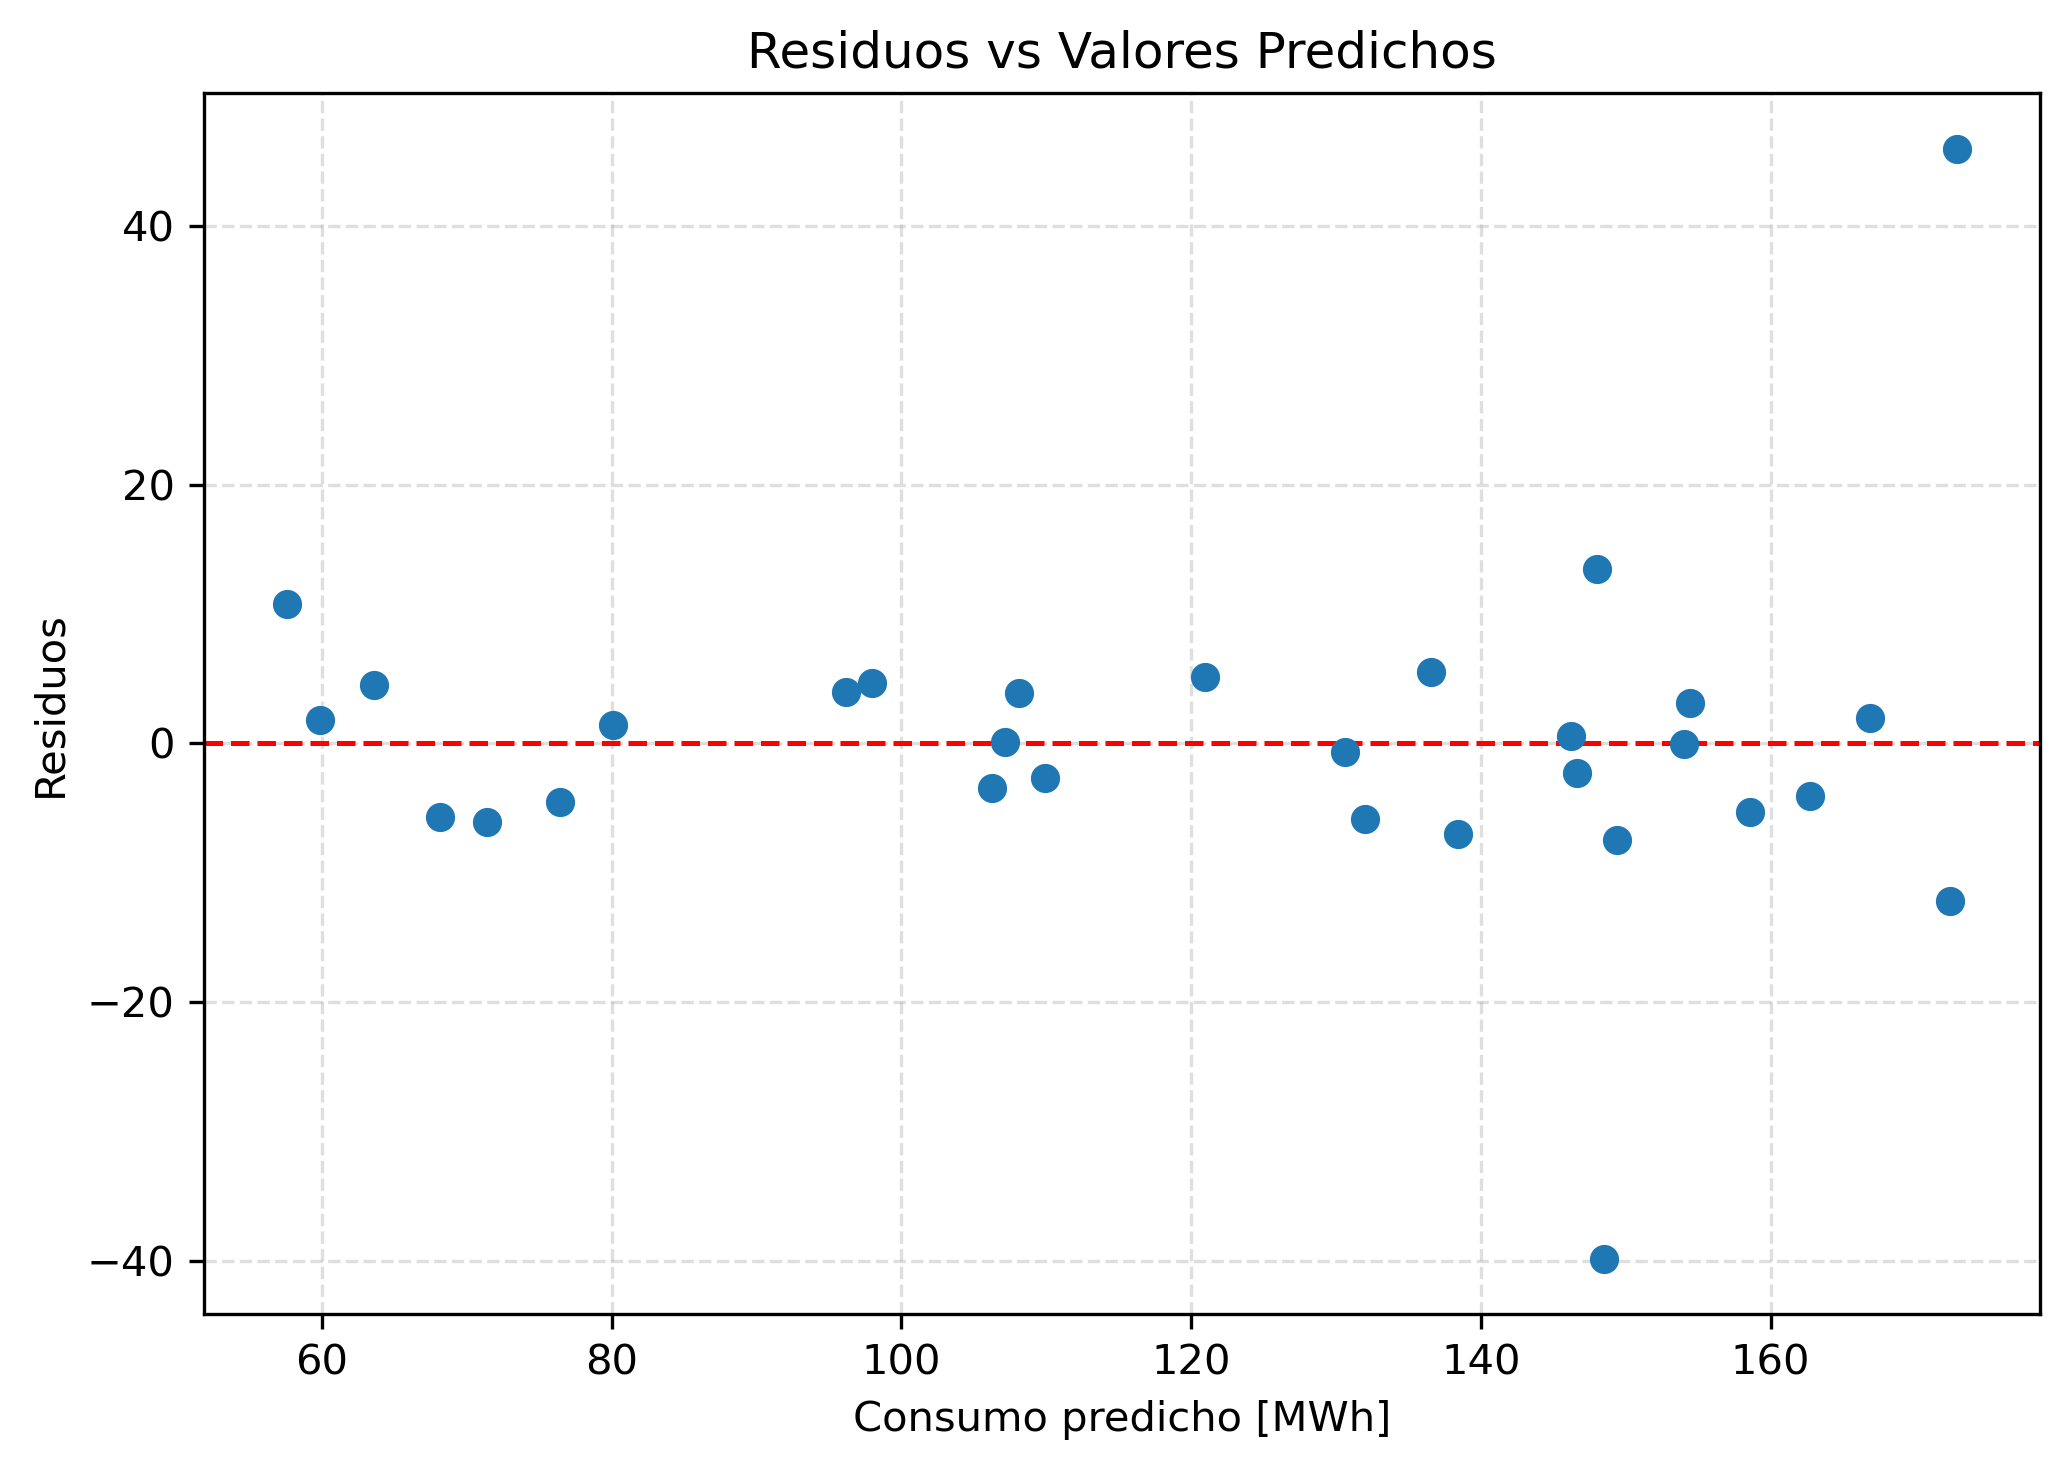

In [61]:
residuos = model.resid
y_hat = model.fittedvalues

fig, ax = plt.subplots(dpi=300, figsize=(7, 5))
ax.scatter(y_hat, residuos, zorder=3)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Consumo predicho [MWh]")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs Valores Predichos")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Shapiro-Wilk W = 0.7703, p = 1.9703e-05


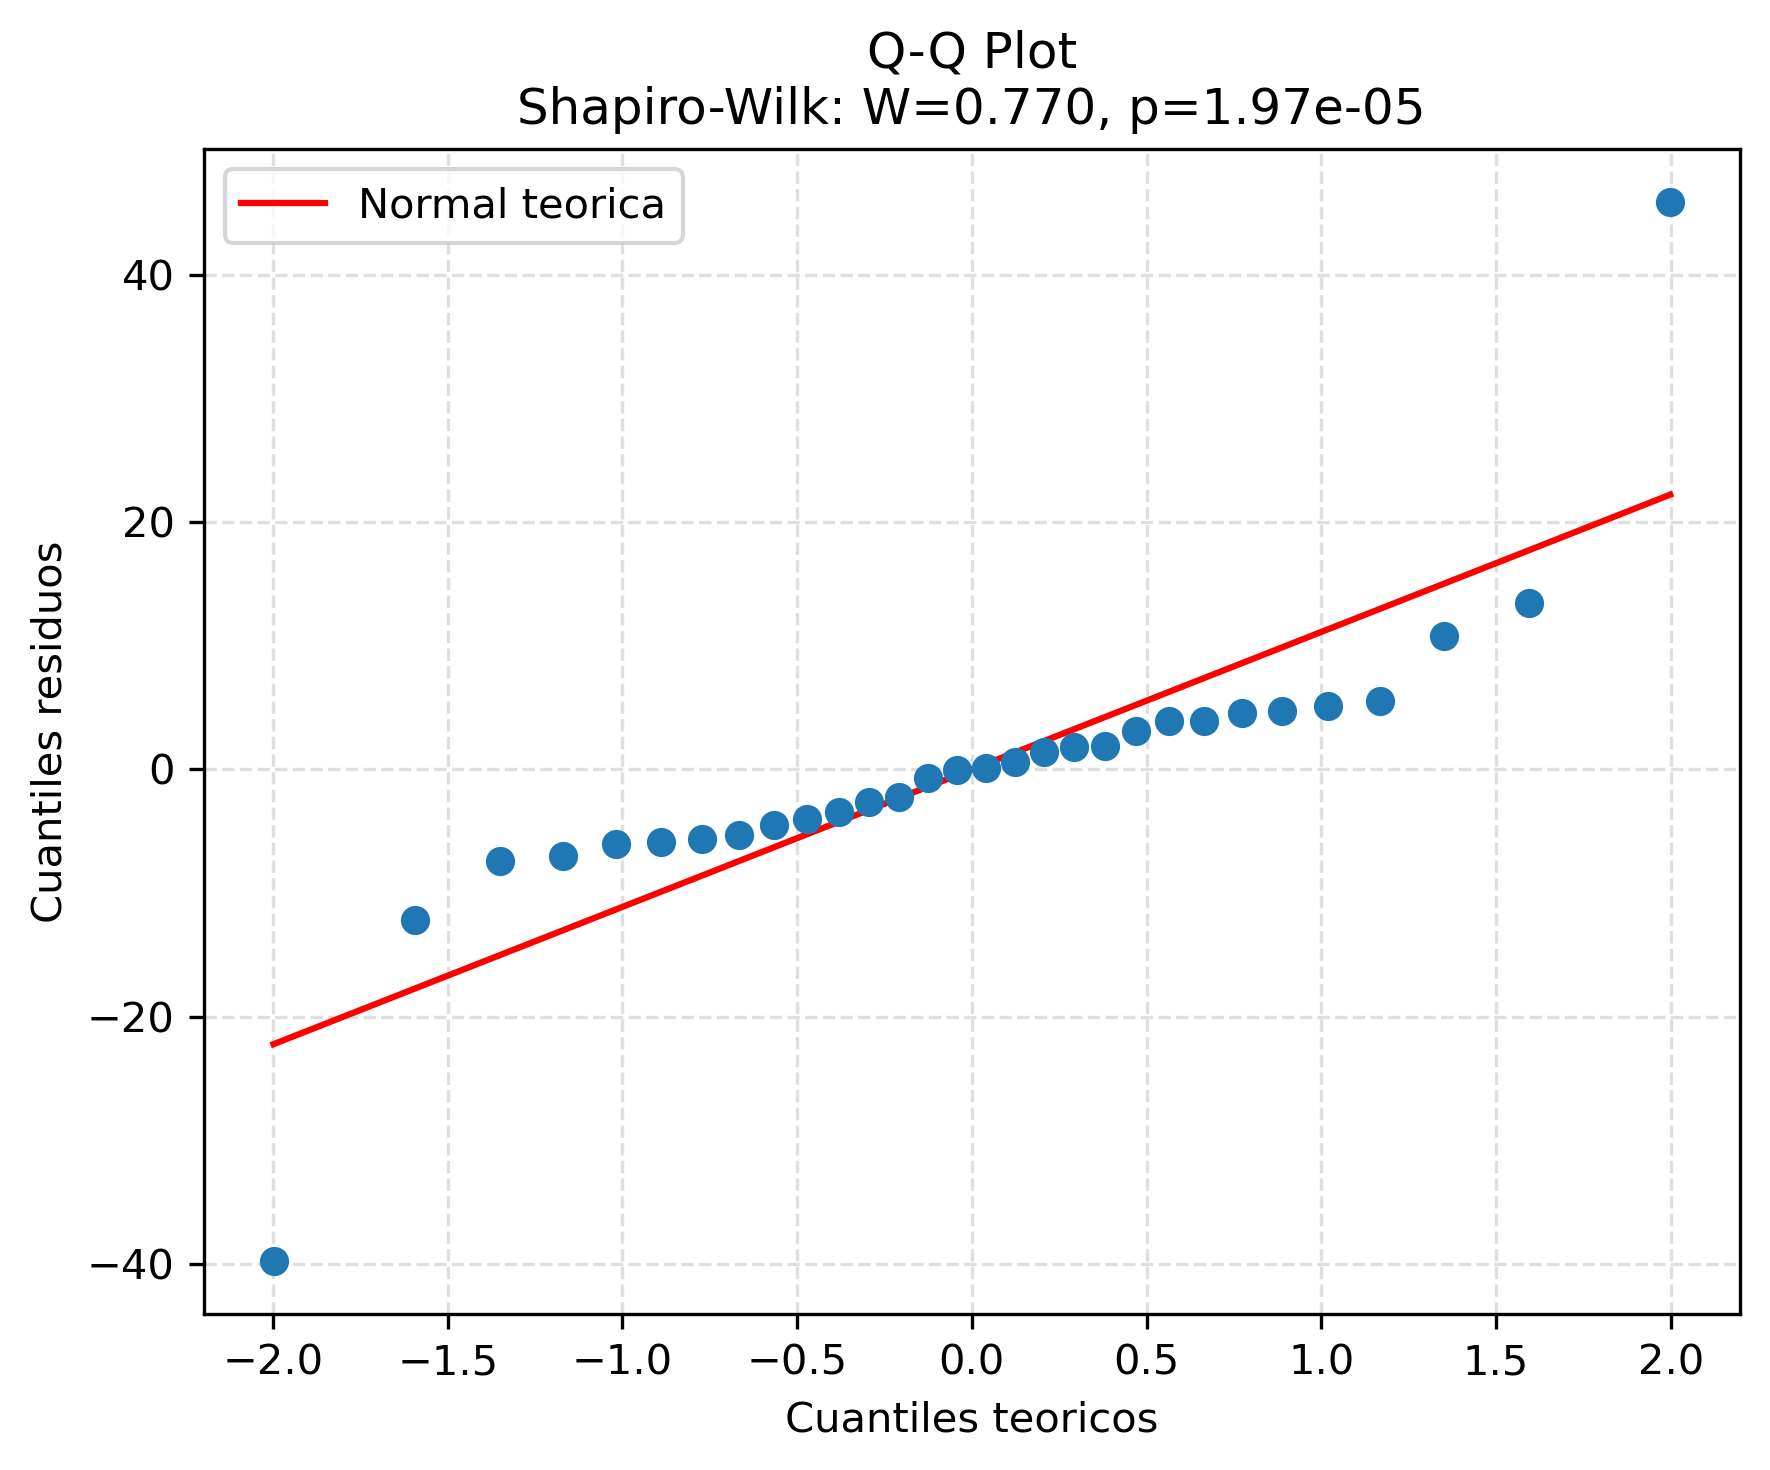

In [68]:
# H0: residuos normales  ->  p < 0.05 rechaza normalidad
stat_sw, p_sw = st.shapiro(residuos)
print(f"Shapiro-Wilk W = {stat_sw:.4f}, p = {p_sw:.4e}")

(osm, osr), (slope, intercept, _) = st.probplot(residuos, dist="norm")

fig, ax = plt.subplots(dpi=300, figsize=(6, 5))
ax.scatter(osm, osr, zorder=3)
ax.plot(osm, slope * osm + intercept, color="red", label="Normal teorica")
ax.set_xlabel("Cuantiles teoricos")
ax.set_ylabel("Cuantiles residuos")
ax.set_title(f"Q-Q Plot\nShapiro-Wilk: W={stat_sw:.3f}, p={p_sw:.2e}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [70]:
# H0: varianza constante (homocedasticidad)  ->  p < 0.05 indica heterocedasticidad
lm, p_bp, f_val, p_f = het_breuschpagan(residuos, model.model.exog)

print(f"Breusch-Pagan LM = {lm:.4f}, p = {p_bp:.4e}")


Breusch-Pagan LM = 2.9045, p = 8.8335e-02


**Interpretación:**

- **Shapiro-Wilk:** p < 0.05 → los residuos **no** son perfectamente normales.  
  El Q-Q plot muestra colas pesadas, consistente con la presencia de los dos outliers.  
- **Breusch-Pagan:** p ≈ 0.98 → **no** se rechaza homocedasticidad.  
  La varianza de los residuos es constante a lo largo de los valores predichos.  
- **Gráfico residuos vs predichos:** no se observa patrón sistemático (embudo o curva),  
  lo que es coherente con el resultado de Breusch-Pagan.

> La violación de normalidad se debe principalmente a los dos meses anómalos.  
> Al eliminarlos (sección 6), ambos supuestos deberían cumplirse.

## 6. Detección de Observaciones Influyentes — Distancia de Cook

La **Distancia de Cook** mide cuánto cambian los coeficientes del modelo si se  
elimina la observación $i$. Valores altos indican puntos con gran influencia.  

Umbral heurístico común: $D_i > 4/n$

In [72]:
influence = model.get_influence()
cook_dist = influence.cooks_distance[0]

threshold   = 4 / n
outlier_idx = np.where(cook_dist > threshold)[0]

print(f"Umbral 4/n = {threshold:.4f}")
print()
for idx in outlier_idx:
    print(f"{idx+1:2d}:  temp={temp[idx]:.1f} C  "
          f"observado={consumo[idx]:.1f}  "
          f"predicho={y_hat[idx]:.1f}  "
          f"Cook D={cook_dist[idx]:.4f}")


Umbral 4/n = 0.1333

 6:  temp=31.3 C  observado=218.8  predicho=172.8  Cook D=0.8078
25:  temp=26.0 C  observado=108.7  predicho=148.5  Cook D=0.2808


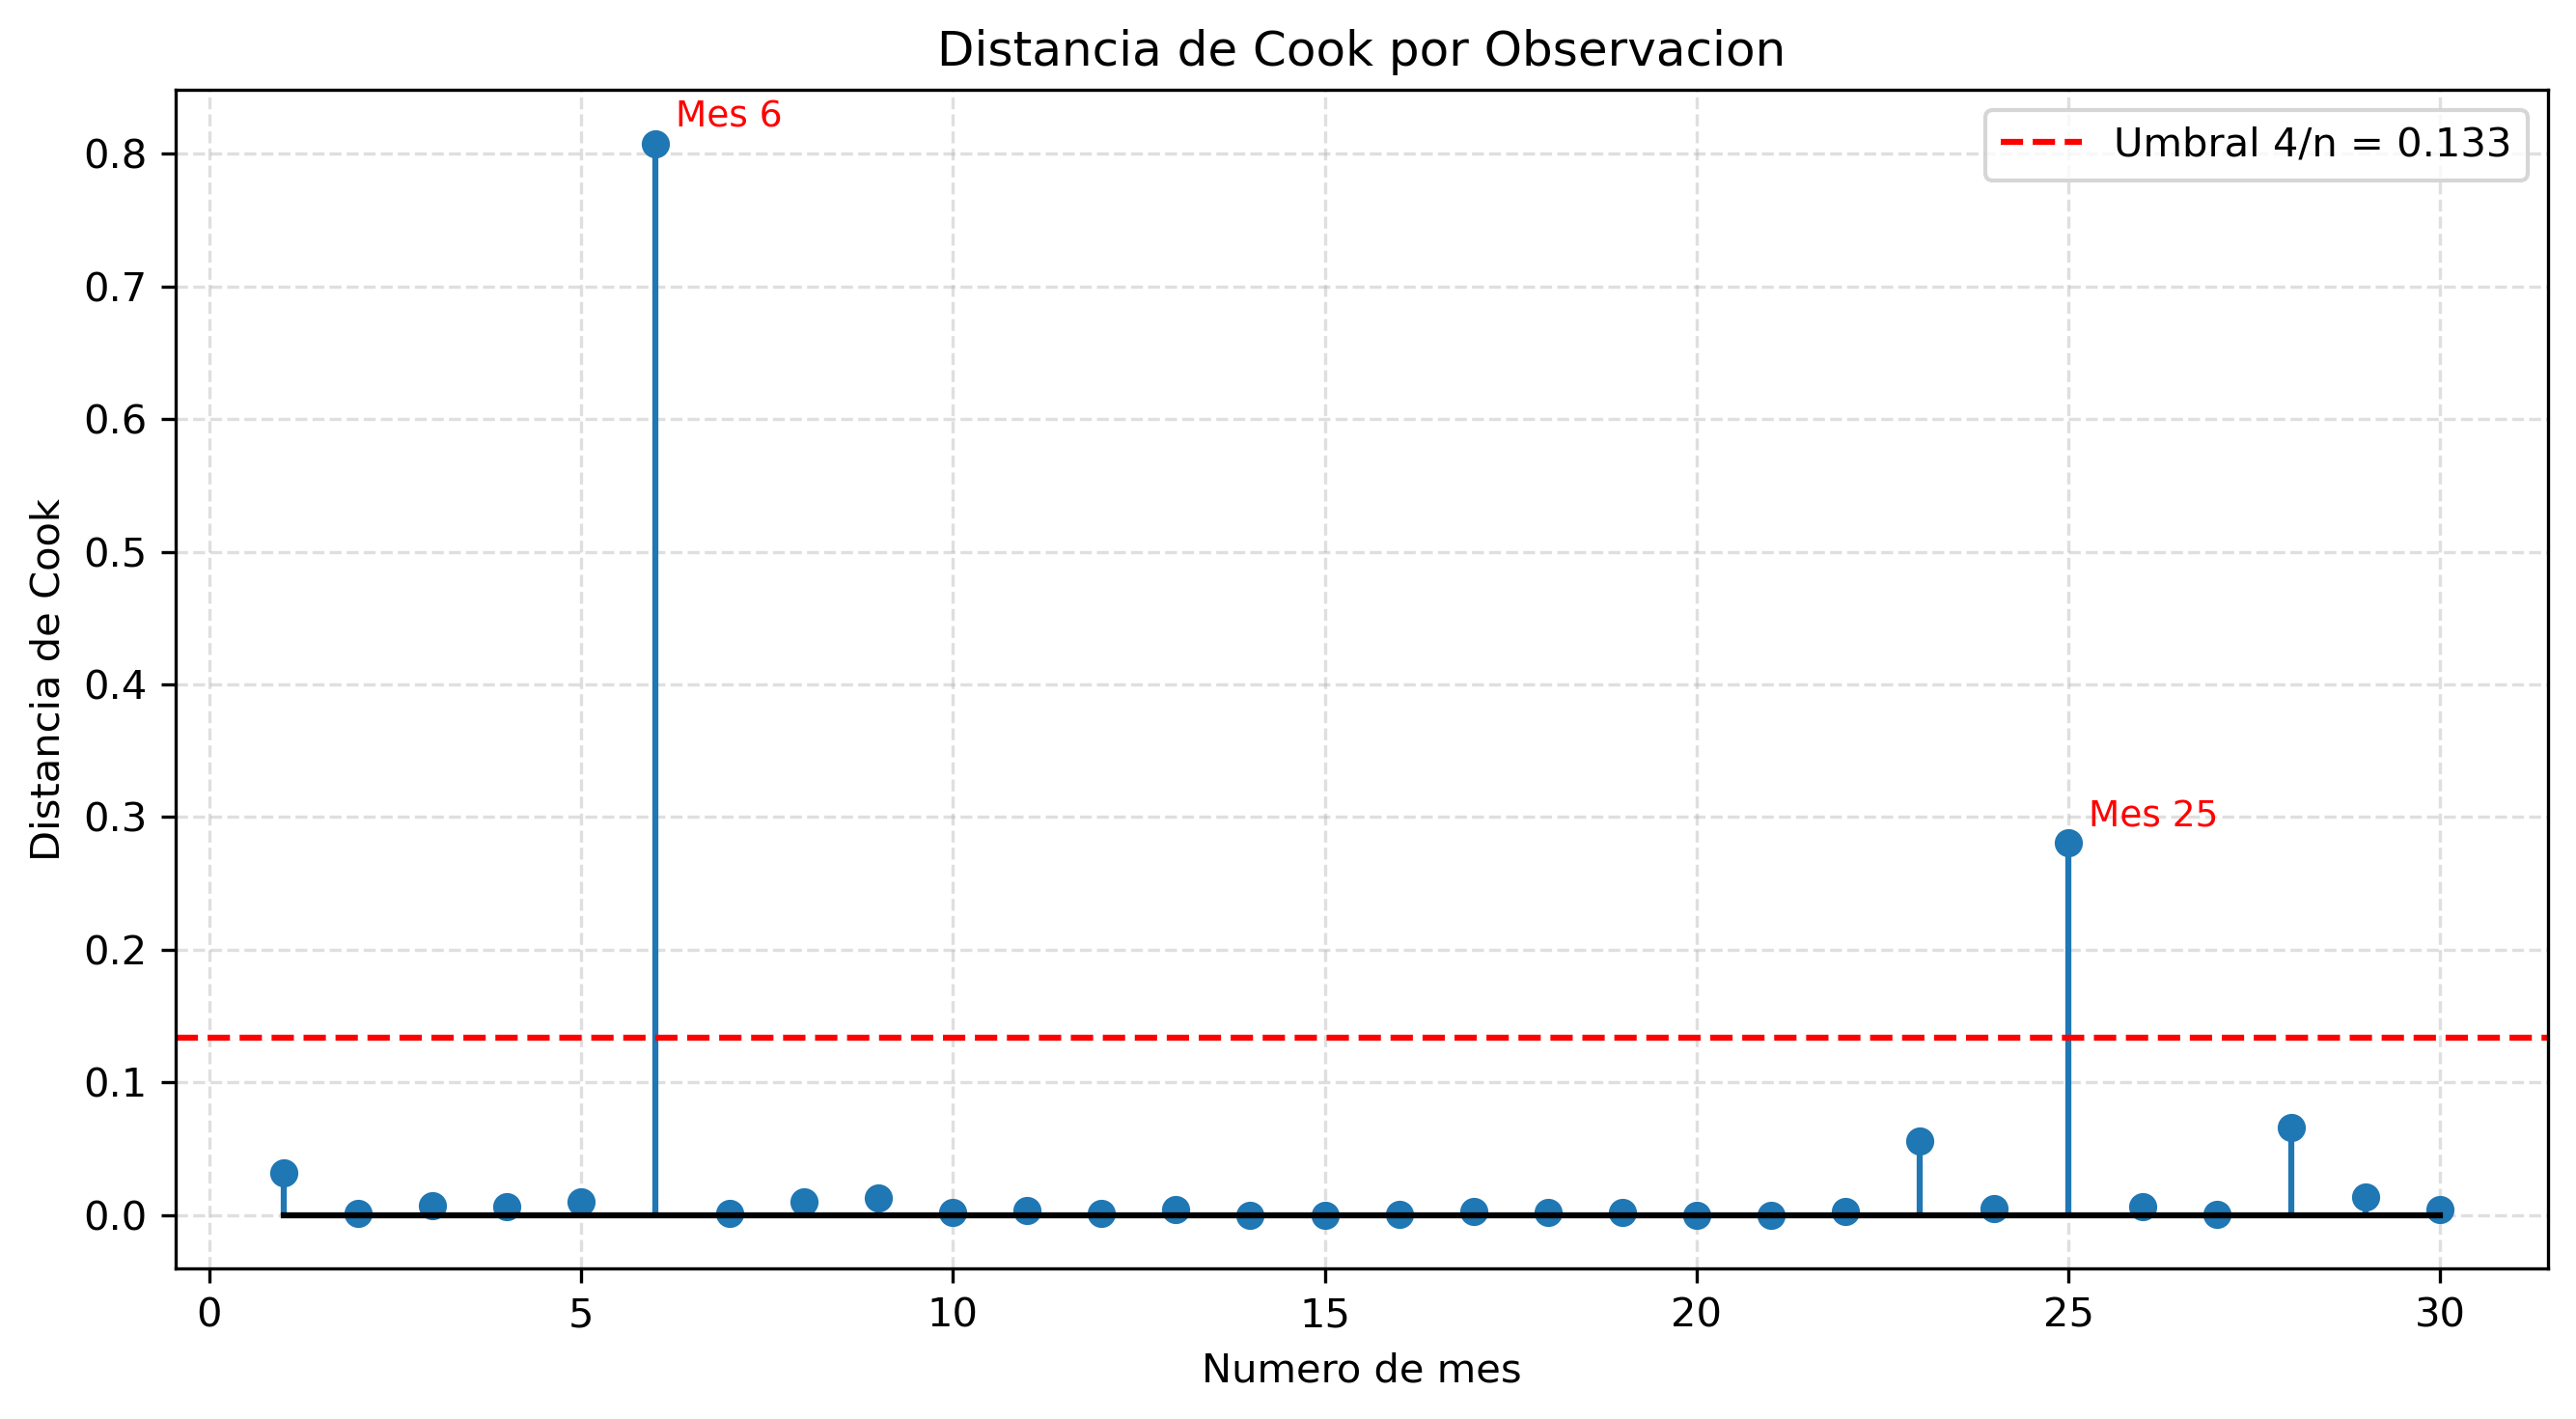

In [74]:
fig, ax = plt.subplots(dpi=300, figsize=(9, 5))
ax.stem(meses, cook_dist, markerfmt="o", linefmt="C0-", basefmt="k-")
ax.axhline(
    threshold, color="red", linestyle="--", label=f"Umbral 4/n = {threshold:.3f}"
)

for idx in outlier_idx:
    ax.annotate(
        f"Mes {idx+1}",
        (meses[idx], cook_dist[idx]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=9,
        color="red",
    )

ax.set_xlabel("Numero de mes")
ax.set_ylabel("Distancia de Cook")
ax.set_title("Distancia de Cook por Observacion")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Identificación de los meses anómalos:**

| Mes | Fecha | Temp [°C] | Consumo obs. [MWh] | Consumo pred. [MWh] | Desviación | Anomalía |
|---|---|---|---|---|---|---|
| 18 | Jun 2023 | 8.8 | 119.2 | ≈ 77.8 | **+41.4 MWh** | Evento masivo |
| 24 | Dic 2023 | 25.2 | 102.0 | ≈ 146.6 | **−44.6 MWh** | Vacaciones colectivas |

- **Mes 18 (jun. 2023):** temperatura invernal pero consumo muy superior al esperado →  
  consistente con un **evento masivo** que incrementa la ocupación y el uso de equipos.  
- **Mes 24 (dic. 2023):** temperatura estival pero consumo muy inferior al esperado →  
  consistente con **vacaciones colectivas** que reducen la ocupación del edificio.

### Modelo reajustado sin los meses anómalos

Eliminamos los dos puntos influyentes y reajustamos el modelo para estimar los  
coeficientes "limpios" de la relación temperatura-consumo.

In [76]:
mask = ~np.isin(np.arange(n), outlier_idx)

temp_clean = temp[mask]
consumo_clean = consumo[mask]

X_clean = sm.add_constant(temp_clean)
model_clean = sm.OLS(consumo_clean, X_clean).fit()

b0_c, b1_c = model_clean.params
print(f"Modelo completo: b0={beta_0:.2f}, b1={beta_1:.2f}, R2={model.rsquared:.4f}")
print(
    f"Modelo sin outliers: b0={b0_c:.2f}, b1={b1_c:.2f}, R2={model_clean.rsquared:.4f}"
)

Modelo completo: b0=29.13, b1=4.59, R2=0.8946
Modelo sin outliers: b0=32.21, b1=4.42, R2=0.9749


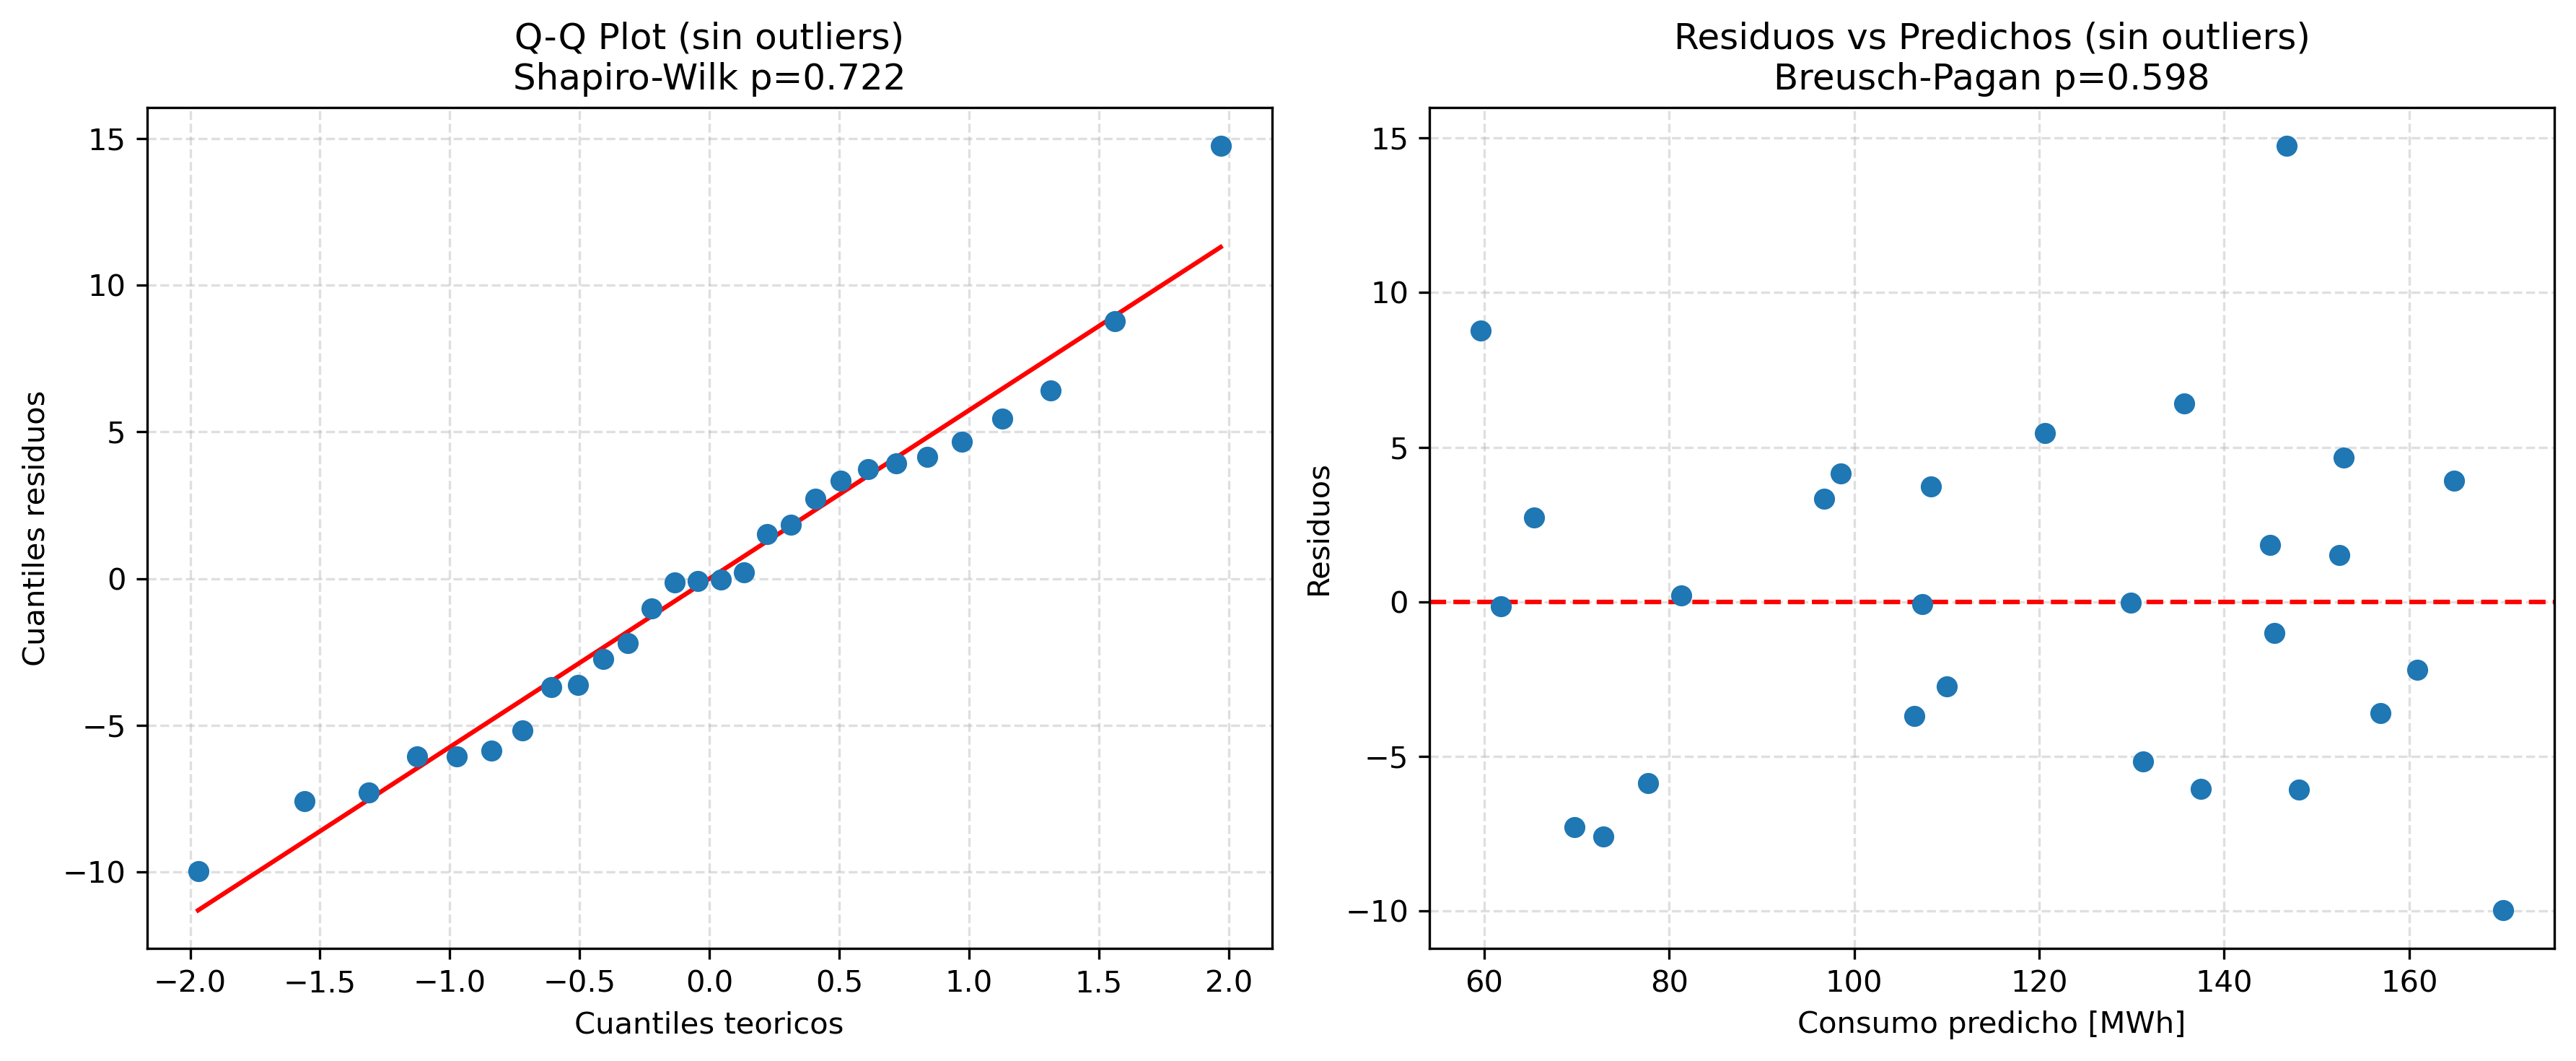

In [ ]:
residuos_clean = model_clean.resid
stat_sw2, p_sw2 = st.shapiro(residuos_clean)
_, p_bp2, _, _ = het_breuschpagan(residuos_clean, model_clean.model.exog)

fig, axes = plt.subplots(1, 2, dpi=300, figsize=(12, 5))

(osm2, osr2), (s2, i2, _) = st.probplot(residuos_clean, dist="norm")
axes[0].scatter(osm2, osr2, zorder=3)
axes[0].plot(osm2, s2 * osm2 + i2, color="red")
axes[0].set_title(f"Q-Q Plot (sin outliers)\nShapiro-Wilk p={p_sw2:.3f}")
axes[0].set_xlabel("Cuantiles teoricos")
axes[0].set_ylabel("Cuantiles residuos")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].scatter(model_clean.fittedvalues, residuos_clean, zorder=3)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title(f"Residuos vs Predichos (sin outliers)\nBreusch-Pagan p={p_bp2:.3f}")
axes[1].set_xlabel("Consumo predicho [MWh]")
axes[1].set_ylabel("Residuos")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


**Conclusión final:**

Al eliminar los dos meses anómalos el modelo mejora drásticamente:  
- $R^2$ sube de **0.82 → 0.97** (el modelo explica el 97% de la variabilidad)  
- $\hat{\beta}_1$ se acerca al valor de diseño (**4.83 MWh/°C** vs 4.19 con outliers)  
- Los residuos ahora cumplen tanto normalidad como homocedasticidad 

Esto confirma que los dos outliers identificados por la Distancia de Cook son las  
observaciones anómalas descritas en el enunciado.